In [4]:
# import sys
# from pathlib import Path
# print(Path.cwd())
# print(Path.cwd().parents[1])
# sys.path.append(str(Path.cwd().parents[1]))
from modeling.CustomDataset import * # .modeling
from modeling.model import *
from modeling.ModelTraining import *
from modeling.utils import *
# from torch.utils.data import WeightedRandomSampler
# from sklearn.model_selection import train_test_split
# from torchinfo import summary

Optuna


torch.amp.autocast
torch gradscaler 

fuse

can use google cloud credits, ask everly if needed

In [5]:
seed=42
if torch.cuda.is_available():
    device = 'cuda' 
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()

else: device = 'cpu'

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prep(seed, device=device) #device = 'gpu'
data = make_dataset(
    start_date="2017-01-01", 
    label_col="events"#, 
    #seed=seed
)
print('Loaded')
in_dim = data.__getitem__(1)[0].shape[0] # may need to be 1
out_dim = 384 # rename
# check 8 better when streamlined
batch_size = 128#8, 16, 32, 64, 128
num_classes = data.get_num_classes() + 1
print('Making dataloaders')
train_loader, dev_loader, test_loader = make_loaders(
    data=data, 
    seed=seed,
    batch_size=batch_size
)
print('Made')

Loading 2017-01-01 dataset...
Loaded
Making dataloaders
Made


In [71]:
len(train_loader.dataset) + len(dev_loader.dataset) + len(test_loader.dataset) == len(df[df['des'].apply(lambda x: x[-1] == ".")])

True

In [ ]:
torch._dynamo.config.suppress_errors = True

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
df = pd.read_csv('data/2017_01_01_data.csv')

In [33]:
df.sample(n=5)[['stand', 'release_pos_x', 'release_pos_y', 'des', 'events']]

,stand,release_pos_x,release_pos_y,des,events
4123135,1,-2.05,54.31,Lewis Brinson strikes out swinging.,5
1186226,1,2.41,54.34,Ball,8
1437948,1,-2.11,54.04,Luke Williams singles on a line drive to cente...,1
270461,0,-2.12,54.44,Called Strike,6
2006832,1,-0.95,54.61,Swinging Strike,5


In [53]:
df[df['des'].apply(lambda x : len(x.split()) > 2)].sample(n=5)[['stand', 'release_pos_x', 'release_pos_y', 'des', 'events']]

,stand,release_pos_x,release_pos_y,des,events
23896,1,-1.49,53.76,Ball In Dirt,5
372767,1,1.87,54.29,Tim Anderson singles on a ground ball to left ...,1
402594,0,1.77,54.74,Juan Centeno singles on a line drive to center...,1
293609,1,0.88,54.68,Dylan Moore strikes out swinging.,5
672855,1,-1.28,53.86,"Jason Delay caught stealing home, catcher Aram...",0


In [66]:
df.iloc[[372767, 402594, 293609, 672855]][['stand', 'release_pos_x', 'release_pos_y', 'des', 'events']]

,stand,release_pos_x,release_pos_y,des,events
372767,1,1.87,54.29,Tim Anderson singles on a ground ball to left fielder Brett Gardner.,1
402594,0,1.77,54.74,"Juan Centeno singles on a line drive to center fielder Adam Engel. Juan Centeno out at 2nd on the throw, center fielder Adam Engel to catcher Omar Narvaez to second baseman Yoan Moncada. J.D. Davis to 3rd.",1
293609,1,0.88,54.68,Dylan Moore strikes out swinging.,5
672855,1,-1.28,53.86,"Jason Delay caught stealing home, catcher Aramis Garcia to shortstop Kyle Farmer to catcher Aramis Garcia.",0


In [50]:
print(len(df))

5031678


In [72]:
df[df['des'].apply(lambda x: x[-1] == ".")].sample(n=5)[['stand', 'release_pos_x', 'release_pos_y', 'des', 'events']]

,stand,release_pos_x,release_pos_y,des,events
3355762,0,-1.51,55.02,"Mike Moustakas grounds out softly, third baseman Josh Donaldson to first baseman Justin Smoak.",6
368842,0,-2.44,54.08,Colt Keith strikes out swinging.,5
3106511,1,-2.16,54.27,Zack Gelof pops out to shortstop Masyn Winn.,6
1516683,1,-1.29,54.22,Christian Vazquez strikes out swinging.,5
357600,0,-1.24,54.45,Jorge Polanco walks.,8


In [ ]:
DF = df.copy()
# DF.dropna(subset=['events'], inplace=True)
# DF.dropna(axis=0, inplace=True)
print(len(df))
print(len(DF))

5031678
5031678


In [2]:
from modeling.optuna_test import *

study = optuna.create_study(direction='maximize', pruner=hyperband_pruner)

study.enqueue_trial({'convert_drop': 0.3, 'convert_trans_drop': 0.0, 'convert_lr': 1e-2, 'convert_decay': 1e-4})
#best
study.enqueue_trial({'convert_drop': 0.05940108962701185, 'convert_trans_drop': 0.3050335807975665, 'convert_lr': 0.0018733083159581281, 'convert_decay': 3.9160393696854795e-06})

study.optimize(objective, n_trials=5, gc_after_trial=True)

torch.cuda.empty_cache()

fig = optuna.visualization.plot_intermediate_values(study)
fig.show()

print("Best hyperparameters:", study.best_trial.params)
print("Best validation similarity:", study.best_trial.value)

[I 2026-03-05 22:42:35,606] A new study created in memory with name: no-name-aeb09520-de57-4607-ac69-6c4daeee5e49
/home/august/code/baseball_prediction/modeling/model.py:109: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.out_transformer = nn.TransformerEncoder(self.out_layer, out_num_layers)


epoch 1 sim: 0.7066184110480321
epoch 2 sim: 0.7084740416904093


/home/august/code/baseball_prediction/modeling/optuna_test.py:125: UserWarning: The reported value is ignored because this `step` 8046 is already reported.
  trial.report(val, i)


epoch 3 sim: 0.7094351846584032
epoch 4 sim: 0.7100434963911713
epoch 5 sim: 0.7104621157494502


[I 2026-03-05 22:48:15,737] Trial 0 finished with value: 0.7104621157494502 and parameters: {'convert_drop': 0.3, 'convert_trans_drop': 0.0, 'convert_lr': 0.01, 'convert_decay': 0.0001}. Best is trial 0 with value: 0.7104621157494502.
/home/august/code/baseball_prediction/modeling/model.py:109: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.out_transformer = nn.TransformerEncoder(self.out_layer, out_num_layers)
[I 2026-03-05 22:49:24,802] Trial 1 pruned. 


...

/home/august/code/baseball_prediction/modeling/optuna_test.py:125: UserWarning: The reported value is ignored because this `step` 8046 is already reported.
  trial.report(val, i)


epoch 3 sim: 0.7094933225312242
epoch 4 sim: 0.7100793266035691


[I 2026-03-05 23:10:34,619] Trial 4 finished with value: 0.71048223871597 and parameters: {'convert_drop': 0.716423360072832, 'convert_trans_drop': 0.9795124410011281, 'convert_lr': 0.003745307271757447, 'convert_decay': 0.0009884118732961672}. Best is trial 3 with value: 0.7105028331872246.


epoch 5 sim: 0.71048223871597


Best hyperparameters: {'convert_drop': 0.2562475342231465, 'convert_trans_drop': 0.3578213098291372, 'convert_lr': 0.010656419855954733, 'convert_decay': 5.414437076899985e-10}
Best validation similarity: 0.7105028331872246


In [6]:
num_heads = 4 # 1
ff_dim = 4 * 32 # 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
convert_drop = 0.2562475342231465 #0.3 # 0.5 for non-cosine 
convert_trans_drop = 0.3578213098291372 #0
convert_num_layers = 4
convert_lr = 0.010656419855954733 #1e-2 # 2
convert_decay = 5.414437076899985e-10 #1e-4 #4
convert_epochs = 10 #20 


# torch.cuda.empty_cache()

sub_convert = Convertion(
    dim_in=in_dim, 
    dim_out=out_dim, 
    in_num_heads=num_heads, 
    in_ff_dim=ff_dim, 
    drop=convert_drop, 
    in_trans_drop=convert_trans_drop,
    in_dim_inner = 32, #32
    in_num_layers=convert_num_layers,
    out_num_heads=1,
    out_ff_dim=1,
    out_trans_drop=1
).to(device=device)
convert_optim = optim.AdamW(params=sub_convert.parameters(), lr=convert_lr, weight_decay=convert_decay) # may want to add weight decay
convert_loss_fn = nn.CosineEmbeddingLoss() 
# convert_loss_fn._get_name
# convert_loss_fn = nn.MSELoss()
sub_convert = torch.compile(sub_convert, mode="reduce-overhead")
convert_mod = ModelTraining(
    model=sub_convert, 
    batch_size=batch_size,
    num_classes=num_classes,
    mod_to_train=4
)
sub_convert = convert_mod.fit(
    # sub_convert, 
    opt=convert_optim, 
    loss_fn=convert_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader,  
    epochs=convert_epochs,
    # mod_to_train=4
    device=device
    )

/home/august/code/baseball_prediction/modeling/model.py:109: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.out_transformer = nn.TransformerEncoder(self.out_layer, out_num_layers)





Fitting OptimizedModule model...


Epochs: 100%|██████████| 10/10 [14:23<00:00, 86.31s/it]


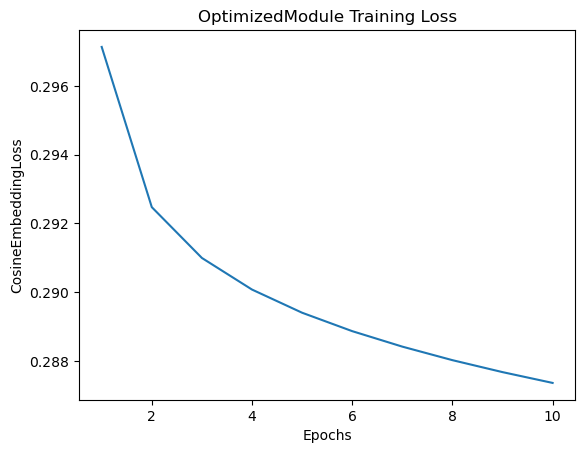

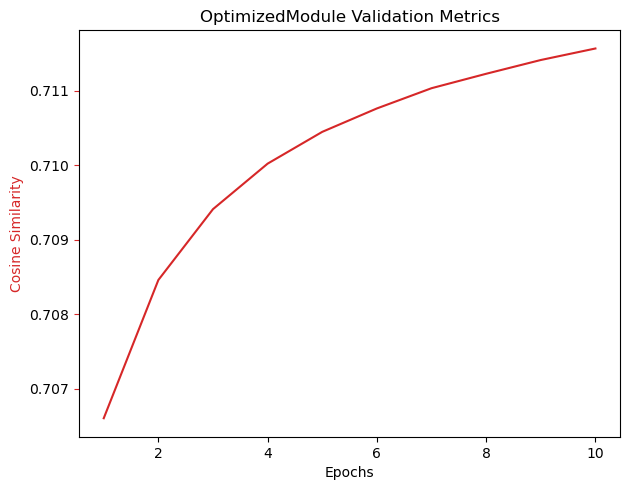

In [7]:
convert_mod.plot_loss()
convert_mod.plot_metrics()

In [8]:
convert_mod.metric

[[tensor(0.7066),
  tensor(0.7085),
  tensor(0.7094),
  tensor(0.7100),
  tensor(0.7104),
  tensor(0.7108),
  tensor(0.7110),
  tensor(0.7112),
  tensor(0.7114),
  tensor(0.7116)],
 []]

In [ ]:
for name, param in convert_mod.model.named_parameters():
    print(name)
    print(param)

pos_embed
Parameter containing:
tensor([[[ 1.7831, -0.0750,  1.1276,  ...,  0.2103, -0.2275,  0.3465],
         [-1.0419,  1.3694,  0.7826,  ..., -0.6434,  0.3828,  1.3010],
         [ 0.2483, -0.4466,  0.8113,  ...,  2.1023, -1.0024, -1.6749],
         ...,
         [-0.0042, -0.0948,  2.2673,  ...,  3.1400, -0.5464,  0.1108],
         [ 0.8950,  0.2782,  1.4513,  ...,  0.3435, -1.0517, -0.1772],
         [-1.3308,  0.3401, -1.4156,  ..., -0.5737, -0.8924, -2.1831]]],
       requires_grad=True)
embed.weight
Parameter containing:
tensor([[ 0.3275],
        [-0.7662],
        [-0.8372],
        [-0.9447],
        [-0.1883],
        [-0.1917],
        [-0.0200],
        [-0.4253],
        [ 0.1333],
        [-0.1788],
        [ 0.9682],
        [ 0.8960],
        [ 0.1657],
        [ 0.6853],
        [ 0.5522],
        [ 0.7305],
        [ 0.0074],
        [-0.7021],
        [-0.0156],
        [-0.9949],
        [ 0.2153],
        [-0.6548],
        [-0.3570],
        [ 0.0962],
        

In [9]:
# NOTE: using if concatenating
sub_in = (out_dim) # + in_dim
sub_drop = 0.3
sub_class = Classification(out_dim, num_classes, sub_drop).to(device)
class_lr = 1e-3 
class_decay = 1e-4
class_optim = optimizer = optim.AdamW(params = sub_class.parameters(), lr=class_lr, weight_decay=class_decay) 
class_loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999)) 
class_mod = ModelTraining(
    sub_class, 
    num_classes=num_classes,
    batch_size=batch_size,
    mod_to_train=2
    )
sub_class = class_mod.fit(
    # model=sub_class, 
    opt=class_optim, 
    loss_fn=class_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader, 
    epochs=5,
    device=device
    
    # batch_size=batch_size
    )




Fitting Classification model...


Epochs: 100%|██████████| 5/5 [01:59<00:00, 23.87s/it]


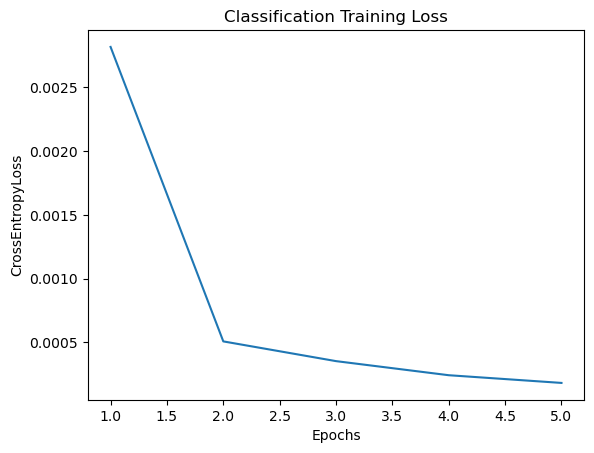

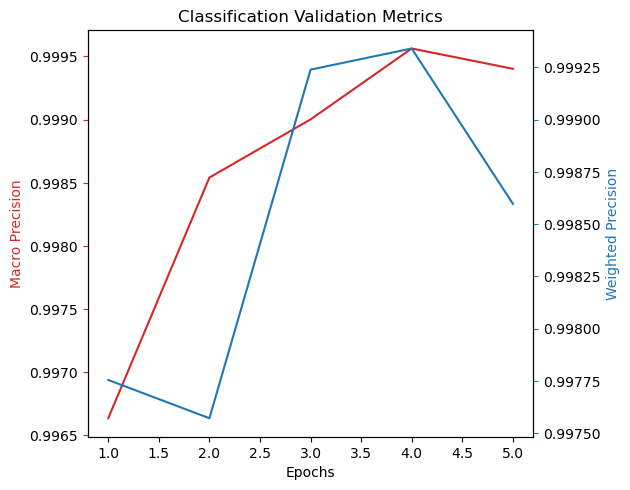

In [10]:
class_mod.plot_loss()
class_mod.plot_metrics()

In [5]:
class_mod.check_preds(dev_loader, mod=2, device=device)

/home/august/miniconda3/envs/cuda/lib/python3.14/site-packages/torch/utils/_device.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


tensor([  166, 18274,  5646,   503,  4089, 28894, 55419,  2770, 10430,  1440,
         1108], device='cuda:0')


In [13]:
# num_heads = 2 
# ff_dim = int((in_dim * (2/3)) + out_dim)
# convert_drop = 0 # 0.5 for non-cosine 
num_heads = 4 # 1
ff_dim = 4 * 32 # 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
convert_drop = 0.3 # 0.5 for non-cosine 
convert_trans_drop = 0
convert_num_layers = 4
sub_convert = Convertion(
    dim_in=in_dim, 
    dim_out=out_dim, 
    in_num_heads=num_heads, 
    in_ff_dim=ff_dim, 
    drop=convert_drop, 
    in_trans_drop=convert_trans_drop,
    # dim_inner = 32,
    in_num_layers=convert_num_layers,
    out_num_heads=1,
    out_ff_dim=1,
    out_trans_drop=1
)
checkpoint = torch.load('best_models/best_OptimizedModule_model.pt', weights_only=True)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint.items()}

sub_convert.load_state_dict(state_dict)
# sub_convert.dim_in = in_dims

sub_in = out_dim # + in_dim
sub_drop = 0.3
simple_sub_class = Classification(out_dim, num_classes, sub_drop).to(device)


drop = 0.5
model = Multi(sub_convert, simple_sub_class, drop, concat=False, freeze=True).to(device) #in_dim, sub_class, False
# print(batch_size, in_dim)
# print(summary(model, input_size=(batch_size, in_dim), device=device))

lr = 1e-2
class_decay = 1e-2

optimizer = optim.AdamW(params = model.parameters(), lr=lr, weight_decay=class_decay) 
# NOTE: need to fix weights
loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean')#weight = calc_loss_weights(data=data, alpha=0.999999)
multi_mod = ModelTraining(
    model, 
    num_classes=num_classes, 
    batch_size=batch_size
    )
model = multi_mod.fit(
    # model, 
    optimizer, 
    loss_fn, 
    train_loader, 
    dev_loader, 
    epochs=5,
    device=device
    )




Fitting Multi model...


Epochs: 100%|██████████| 5/5 [03:44<00:00, 45.00s/it]


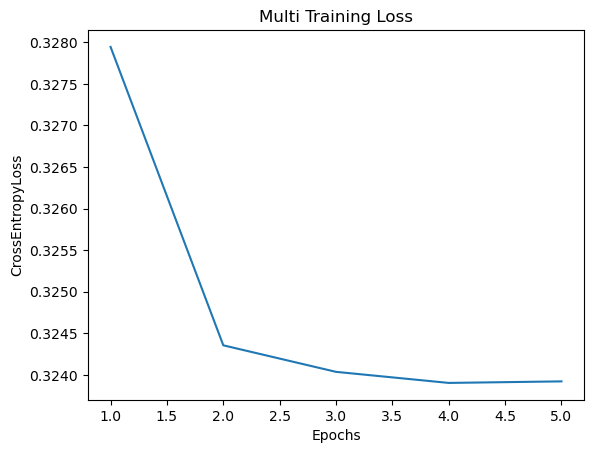

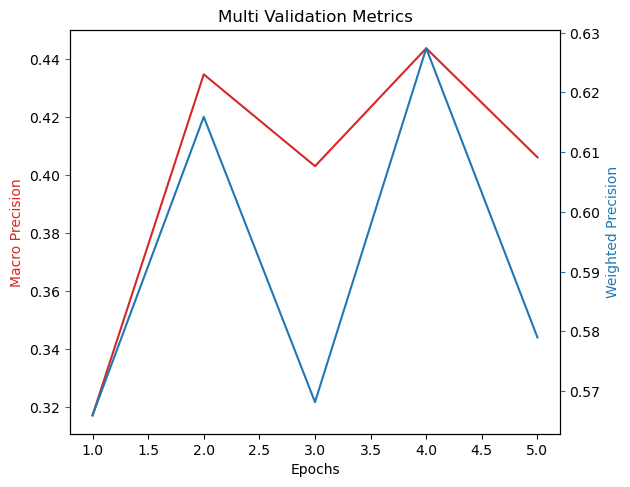

In [14]:
# frozen pretrained
multi_mod.plot_loss()
multi_mod.plot_metrics()

In [15]:
num_heads = 4 # 1
ff_dim = 4 * 32 # 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
convert_drop = 0.3 # 0.5 for non-cosine 
convert_trans_drop = 0
convert_num_layers = 4
sub_convert = Convertion(
    dim_in=in_dim, 
    dim_out=out_dim, 
    in_num_heads=num_heads, 
    in_ff_dim=ff_dim, 
    drop=convert_drop, 
    in_trans_drop=convert_trans_drop,
    # dim_inner = 32,
    in_num_layers=convert_num_layers,
    out_num_heads=1,
    out_ff_dim=1,
    out_trans_drop=1
)
checkpoint = torch.load('best_models/best_OptimizedModule_model.pt', weights_only=True)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint.items()}

sub_convert.load_state_dict(state_dict)
# sub_convert.dim_in = in_dims

sub_in = out_dim # + in_dim
sub_drop = 0.3
simple_sub_class = Classification(out_dim, num_classes, sub_drop).to(device)


drop = 0.5
model = Multi(sub_convert, simple_sub_class, drop, concat=False, freeze=False).to(device) #in_dim, sub_class, False
# print(batch_size, in_dim)
# print(summary(model, input_size=(batch_size, in_dim), device=device))

lr = 1e-2
class_decay = 1e-2

optimizer = optim.AdamW(params = model.parameters(), lr=lr, weight_decay=class_decay) 
# NOTE: need to fix weights
loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean')#weight = calc_loss_weights(data=data, alpha=0.999999)
unfroz_mod = ModelTraining(
    model, 
    num_classes=num_classes, 
    batch_size=batch_size
    )
model = unfroz_mod.fit(
    # model, 
    optimizer, 
    loss_fn, 
    train_loader, 
    dev_loader, 
    epochs=5,
    device=device
    )

/home/august/code/baseball_prediction/modeling/model.py:109: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.out_transformer = nn.TransformerEncoder(self.out_layer, out_num_layers)





Fitting Multi model...


Epochs: 100%|██████████| 5/5 [06:52<00:00, 82.54s/it]


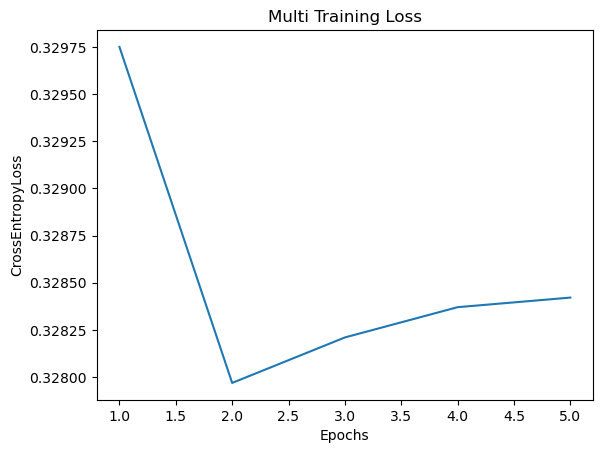

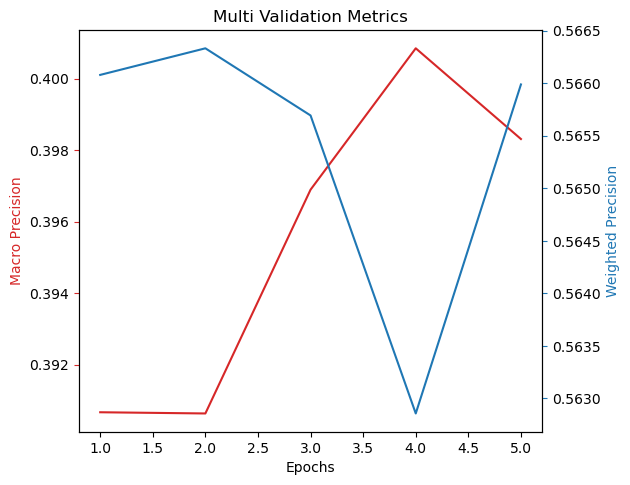

In [16]:
# unfrozen pretrained
unfroz_mod.plot_loss()
unfroz_mod.plot_metrics()

In [17]:
num_heads = 4 # 1
ff_dim = 4 * 32 # 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
convert_drop = 0.3 # 0.5 for non-cosine 
convert_trans_drop = 0
convert_num_layers = 4
sub_convert = Convertion(
    dim_in=in_dim, 
    dim_out=out_dim, 
    in_num_heads=num_heads, 
    in_ff_dim=ff_dim, 
    drop=convert_drop, 
    in_trans_drop=convert_trans_drop,
    # dim_inner = 32,
    in_num_layers=convert_num_layers,
    out_num_heads=1,
    out_ff_dim=1,
    out_trans_drop=1
)
# checkpoint = torch.load('best_models/best_OptimizedModule_model.pt', weights_only=True)
# state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint.items()}

# sub_convert.load_state_dict(state_dict)
# sub_convert.dim_in = in_dims

sub_in = out_dim # + in_dim
sub_drop = 0.3
simple_sub_class = Classification(out_dim, num_classes, sub_drop).to(device)


drop = 0.5
model = Multi(sub_convert, simple_sub_class, drop, concat=False, freeze=False).to(device) #in_dim, sub_class, False
# print(batch_size, in_dim)
# print(summary(model, input_size=(batch_size, in_dim), device=device))

lr = 1e-2
class_decay = 1e-2

optimizer = optim.AdamW(params = model.parameters(), lr=lr, weight_decay=class_decay) 
# NOTE: need to fix weights
loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean')#weight = calc_loss_weights(data=data, alpha=0.999999)
all_mod = ModelTraining(
    model, 
    num_classes=num_classes, 
    batch_size=batch_size
    )
model = all_mod.fit(
    # model, 
    optimizer, 
    loss_fn, 
    train_loader, 
    dev_loader, 
    epochs=5,
    device=device
    )




Fitting Multi model...


Epochs: 100%|██████████| 5/5 [07:07<00:00, 85.41s/it]


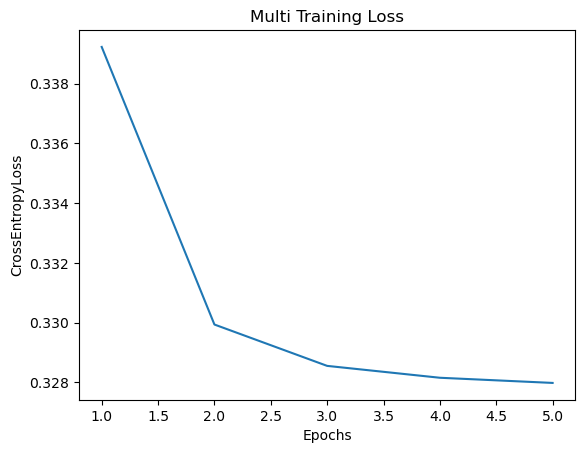

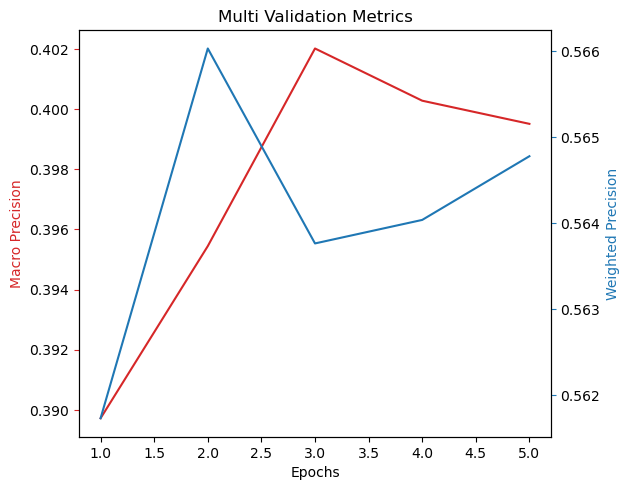

In [18]:
# unfrozen non-pretrained
all_mod.plot_loss()
all_mod.plot_metrics()

In [19]:
multi_mod.check_preds(dev_loader, device=device)

/home/august/miniconda3/envs/cuda/lib/python3.14/site-packages/torch/utils/_device.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


tensor([   59,     0,     0,     0,     0, 31797, 87668,     3,  8410,   802,
            0], device='cuda:0')


In [19]:
# classification for just game state
game_drop = 0.3
# print(in_dim)
game_class = Classification(in_dim, num_classes, game_drop).to(device) #, num_hidden=3
game_lr = 1e-2
game_decay = 1e-3
game_optim = optimizer = optim.AdamW(params = game_class.parameters(), lr=game_lr, weight_decay=game_decay) 
game_loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean') # , label_smoothing=0.05 
game_mod = ModelTraining(
    game_class,
    num_classes=num_classes,
    batch_size=batch_size,
    mod_to_train=0
    )
game_class = game_mod.fit(
    # model=game_class, 
    opt=game_optim, 
    loss_fn=game_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader, 
    # num_classes=num_classes,
    epochs=5,
    device=device
    # mod_to_train=0,
    # batch_size=batch_size
    )




Fitting Classification model...


Epochs: 100%|██████████| 5/5 [02:05<00:00, 25.05s/it]


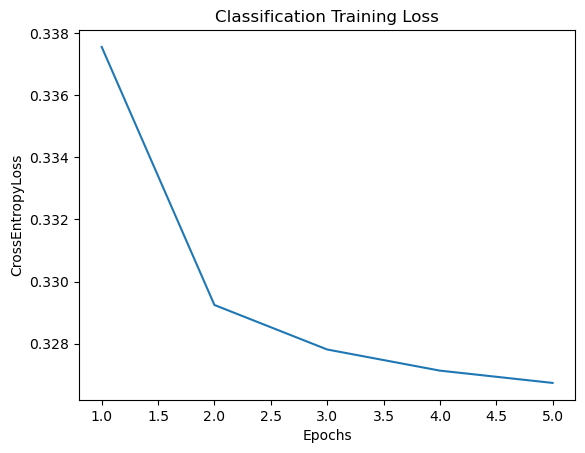

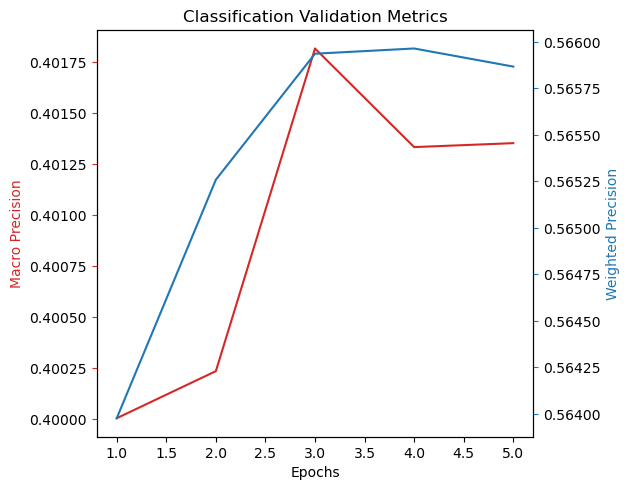

In [20]:
game_mod.plot_loss()
game_mod.plot_metrics()

In [18]:
game_mod.best_metric

[tensor(0.4924, device='cuda:0'), -1]

In [ ]:
game_mod.check_preds(dev_loader)

RuntimeError: stack expects each tensor to be equal size, but got [128, 78] at entry 0 and [99, 78] at entry 1005

In [22]:
# num_heads = 4 # 1
# ff_dim = 4 * 32 # 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
# convert_drop = 0.3 # 0.5 for non-cosine 
# convert_trans_drop = 0
# convert_num_layers = 4
# sub_convert = Convertion(
#     dim_in=in_dim, 
#     dim_out=out_dim, 
#     in_num_heads=num_heads, 
#     in_ff_dim=ff_dim, 
#     drop=convert_drop, 
#     in_trans_drop=convert_trans_drop,
#     # dim_inner = 32,
#     in_num_layers=convert_num_layers,
#     out_num_heads=1,
#     out_ff_dim=1,
#     out_trans_drop=1
# )
# checkpoint = torch.load('best_models/best_OptimizedModule_model.pt', weights_only=True)
# state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint.items()}

# sub_convert.load_state_dict(state_dict)

# sub_convert.check_preds(test_loader)
convert_mod.validation(test_loader, device=device)

[tensor(0.7116, device='cuda:0')]

In [23]:
class_mod.validation(test_loader, device=device)

[tensor(0.9994, device='cuda:0'), tensor(0.9987, device='cuda:0')]

In [24]:
game_mod.validation(test_loader, device=device)

[tensor(0.4032, device='cuda:0'), tensor(0.5657, device='cuda:0')]

In [25]:
multi_mod.validation(test_loader, device=device)

[tensor(0.4328, device='cuda:0'), tensor(0.6117, device='cuda:0')]

In [26]:
unfroz_mod.validation(test_loader, device=device)

[tensor(0.4008, device='cuda:0'), tensor(0.5660, device='cuda:0')]

In [27]:
all_mod.validation(test_loader, device=device)

[tensor(0.4028, device='cuda:0'), tensor(0.5652, device='cuda:0')]



0 other
1 single 
2 double 
3 triple 
4 homerun 
5 strikeout
6 out 
7 multi out
8 walk 
9 awarded first 
10 field 



3 double 
12 hr
18 single
(19) strike out
21 tripple 

out: 6, 8, 9, 14, 16

double play (mult out): 4, 10, 15, 17, 20, 22

walk: 13, 24

awarded first: 2, 11

other: 2, 23 (5)

field thing: 5, 7 


no strike out or walks??